# Forward Model Example: Cosmic Background Radiation 

## Fitting the Cosmic Microwave Background: Blackbody Radiation with Planck's Law

## Introduction

In this notebook, we analyze the spectrum of the **Cosmic Microwave Background (CMB)** radiation — the afterglow of the Big Bang. The CMB is one of the strongest pieces of evidence for the Big Bang theory and follows the spectrum of a nearly perfect **blackbody**.

We will use **Planck's law** to model the intensity of blackbody radiation as a function of wavelength and temperature. By fitting this theoretical curve to experimental or simulated data, we can determine the temperature of the CMB and a scaling factor that accounts for experimental conditions (such as detector area, efficiency, or calibration).

### Planck's Law

The spectral radiance of a blackbody is given by Planck's formula:

$$
B(\lambda, T) = \frac{2hc^2}{\lambda^5} \frac{1}{e^{hc/(\lambda kT)} - 1}
$$

where:
- $h$ is **Planck's constant** ($6.62607015 \times 10^{-34}$ J·s)
- $c$ is the **speed of light** ($2.998 \times 10^8$ m/s)
- $k$ is **Boltzmann's constant** ($1.380649 \times 10^{-23}$ J/K)
- $\lambda$ is the **wavelength** (in meters)
- $T$ is the **temperature** of the blackbody (in Kelvin)

In practice, measured intensity often includes an overall scaling factor $A$ due to experimental setup. Our model therefore becomes:

$$
I(\lambda, T, A) = A \cdot \frac{2hc^2}{\lambda^5} \frac{1}{e^{hc/(\lambda kT)} - 1}
$$

### What We'll Do

1. Define the physical constants and the Planck function.
2. Use `scipy.optimize.curve_fit` to find the best-fit values for the temperature $T$ and scaling factor $A$.
3. Plot the measured data points together with the fitted curve.
4. Report the fitted temperature of the Cosmic Microwave Background.

The expected temperature of the CMB is approximately **2.72 K** — one of the most precisely measured values in cosmology.

---



In [44]:
#Load data from data.csv and print the first 5 rows.
import pandas as pd
data = pd.read_csv('data.csv')
print(data.head())

   Wavelength   Intensity
0    0.516338    0.216933
1    0.548758    0.282212
2    0.573032    0.343468
3    0.593078    0.408856
4    0.619386    0.461920


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize


#store columns #1 and #2 to numpy arrays wavelength_data and intensity_data respectively.
wavelength_data = data.iloc[:, 0].to_numpy()
intensity_data = data.iloc[:, 1].to_numpy()

In [46]:
#The wavelengths are in mm, converting them to meters. (Can do any other experimental calibrations here if needed.)
wavelength_data = wavelength_data * 1e-3

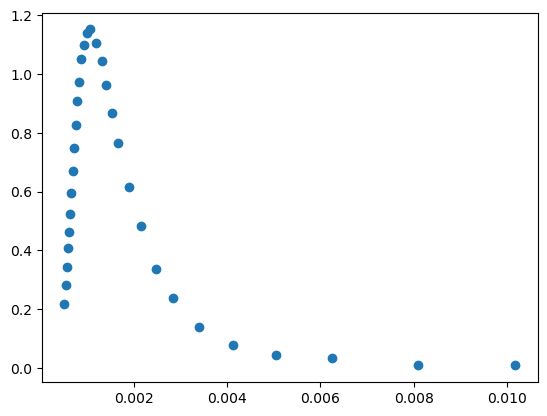

In [47]:
plt.plot(wavelength_data, intensity_data, 'o', label='Data')

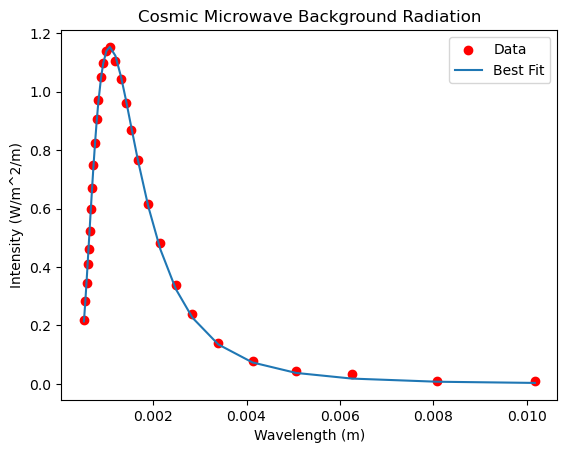

Best fit temperature T: 2.709539323397489 K
Best fit scaling factor A: 1928.4759651171464


In [50]:
# Now, let's do physics 
h=6.62607015e-34 # Planck's constant in J*s
k=1.380649e-23 # Boltzmann's constant in J/K
c=2.998e8 # Speed of light in m/s

# T is the temperature of the blackbody radiation, which we will fit for.
# y is intesity in W/m^2/m.

# A is scaling factor to account for any experimental calibration factors, such as the area of the detector, etc. We will fit for A as well.

# function for evaluating the plank black-body radiation formula at a given wavelength and temperature.
def planck(wavelength, T, A):
    return (A * (2.0 * h * c**2) / (wavelength**5) / (np.exp(h * c / (wavelength * k * T)) - 1.0))

initial_guess = [1,2] # Initial guess for T and A

# find optimal parameters T and A that best fit the data using curve_fit.
params, covariance = optimize.curve_fit(planck, wavelength_data, intensity_data, p0=initial_guess)  

plt.scatter(wavelength_data, intensity_data, label='Data', color='red')
plt.plot(wavelength_data, planck(wavelength_data, *params), label='Best Fit')
plt.xlabel('Wavelength (m)')
plt.ylabel('Intensity (W/m^2/m)')
plt.title('Cosmic Microwave Background Radiation')
plt.legend()
plt.show()

# Print the best fit parameters T and A.
print(f"Best fit temperature T: {params[0]} K")
print(f"Best fit scaling factor A: {params[1]}")

# Inverse Model Example: Determining model parameters: 

## Bayesian Inference with MCMC for CMB Temperature

## Introduction

Having obtained a point estimate of the Cosmic Microwave Background (CMB) temperature and scaling factor using least-squares curve fitting, we now perform a full **Bayesian analysis** using **Markov Chain Monte Carlo (MCMC)** sampling.

This approach provides several advantages:
- It explores the full posterior probability distribution of the parameters rather than just finding a single best-fit point.
- It naturally quantifies uncertainties and parameter degeneracies.
- It allows us to incorporate prior information about plausible values of temperature and scaling factor.

We use the `emcee` package to sample from the posterior distribution defined by:

$$
p(T, A | \text{data}) \propto p(\text{data} | T, A) \times p(T, A)
$$

where:
- The **likelihood** assumes Gaussian errors with constant \(\sigma = 0.1\)
- The **prior** is uniform within reasonable bounds: \(0 < T < 100\) K and \(0 < A < 10\)

### MCMC Configuration
- Number of parameters (`ndim`): 2 (Temperature \(T\) and scaling \(A\))
- Number of walkers: 50
- Steps per walker: 5000
- Initial positions are seeded from the previous curve-fit result
- Burn-in discarded and chain thinned for cleaner samples

After running the sampler, we compute the mean of the posterior samples as our best-fit estimates.

---

### Running MCMC sampling for the blackbody parameters...

In [54]:
# MCMC to find model parameters, given data and model.
import emcee
# Define the log-likelihood function for MCMC
def log_likelihood(theta, wavelength, intensity):
    T, A = theta
    model = planck(wavelength, T, A)
    sigma2 = 0.1 ** 2  # Assuming a constant error for simplicity
    return -0.5 * np.sum((intensity - model) ** 2 / sigma2) 
# Define the log-prior function for MCMC
def log_prior(theta):
    T, A = theta
    if 0 < T < 100 and 0 < A < 10:  # Priors for T and A
        return 0.0
    return -np.inf  # Log-prior is -inf outside the bounds
# Define the log-posterior function for MCMC
def log_posterior(theta, wavelength, intensity):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, wavelength, intensity)
# Set up the MCMC sampler
ndim = 2  # Number of parameters (T and A)
nwalkers = 50  # Number of MCMC walkers
initial_pos = params + 1e-4 * np.random.randn(nwalkers, ndim)  # Initial positions for the walkers
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(wavelength_data, intensity_data))
# Run the MCMC sampler
sampler.run_mcmc(initial_pos, 5000, progress=True)
# Extract the samples and compute the best-fit parameters
samples = sampler.get_chain(discard=100, thin=15, flat=True)
T_mcmc, A_mcmc = np.mean(samples, axis=0)
print(f"Best-fit parameters from MCMC: T = {T_mcmc:.2f} K, A = {A_mcmc:.2f}")   



  0%|          | 0/5000 [00:00<?, ?it/s]/home/eek/anaconda3/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [00:01<00:00, 3061.21it/s]

Best-fit parameters from MCMC: T = 2.71 K, A = 1928.48


# Curve Fitting vs. MCMC: Key Differences

## Summary of the Two Approaches

We have now analyzed the Cosmic Microwave Background data using two different methods:

### 1. Least-Squares Curve Fitting (`scipy.optimize.curve_fit`)
- Finds the **single best-fit** values for \( T \) and \( A \) by minimizing the sum of squared residuals.
- Fast and simple.
- Provides point estimates but **limited uncertainty information** (only through the covariance matrix).
- Assumes Gaussian errors and does not incorporate prior knowledge.

### 2. Markov Chain Monte Carlo (MCMC) with `emcee`
- Explores the full **posterior probability distribution** of the parameters using Bayesian statistics.
- Samples many possible values of \( T \) and \( A \) weighted by how well they fit the data and our priors.
- Naturally provides **uncertainties, confidence intervals, and correlations** between parameters.
- More robust for complex models and when prior information is available.

**In short**:  
Curve fitting gives you the "best single answer".  
MCMC gives you the full picture — **how certain** we are about that answer and what other values are plausible.

# Visualizing the Posterior Distribution with a Corner Plot

## Understanding the MCMC Results

After running the MCMC sampler, we have a set of samples from the posterior distribution of the parameters \( T \) (temperature) and \( A \) (scaling factor).

A **corner plot** (also called a triangle plot) is an excellent way to visualize this posterior:

- The **diagonal** shows the marginalized 1D posterior distribution (histogram) for each parameter, along with the median and 68% confidence intervals.
- The **off-diagonal** panels show the 2D joint posterior distributions, revealing any correlations or degeneracies between \( T \) and \( A \).

### Why it matters
The corner plot gives us much more insight than a simple best-fit value:
- It shows the **uncertainty** on each parameter.
- It reveals whether the parameters are correlated (tilted contours).
- It helps diagnose whether the MCMC chains have converged well.

Let's generate the corner plot using the `corner` package:



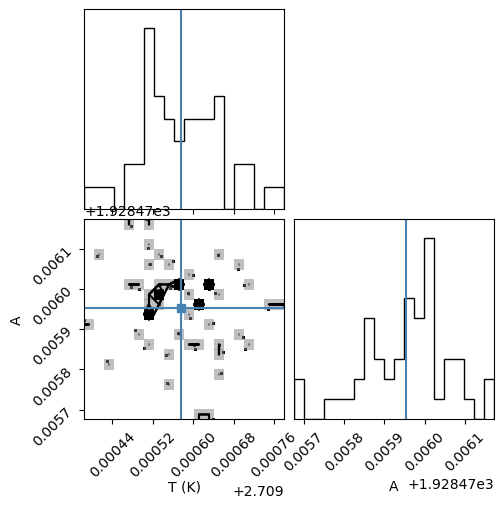

In [55]:
# Corner plot to visualize the posterior distributions of T and A.
import corner
fig = corner.corner(samples, labels=["T (K)", "A"], truths=[T_mcmc, A_mcmc])
plt.show()  

#DATA: 
http://hyperphysics.phy-astr.gsu.edu/hbase/bkg3k.html#c1